In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from RQ1_synth_data.train_synth import run

/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs-legacy.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/amar-mesic/dna-thesis/e/DNAT-43


2025-06-27 17:24:14 INFO     Logs will be written to output/real_data-best_unet-use_scheduler-delta_0.01_100-epoch/20250627_172414/log_training.txt
2025-06-27 17:24:14 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:24:14 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:24:14 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:24:14 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:24:14 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:24:14 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:24:14 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:24:14 WARNING  Size standard peaks valid

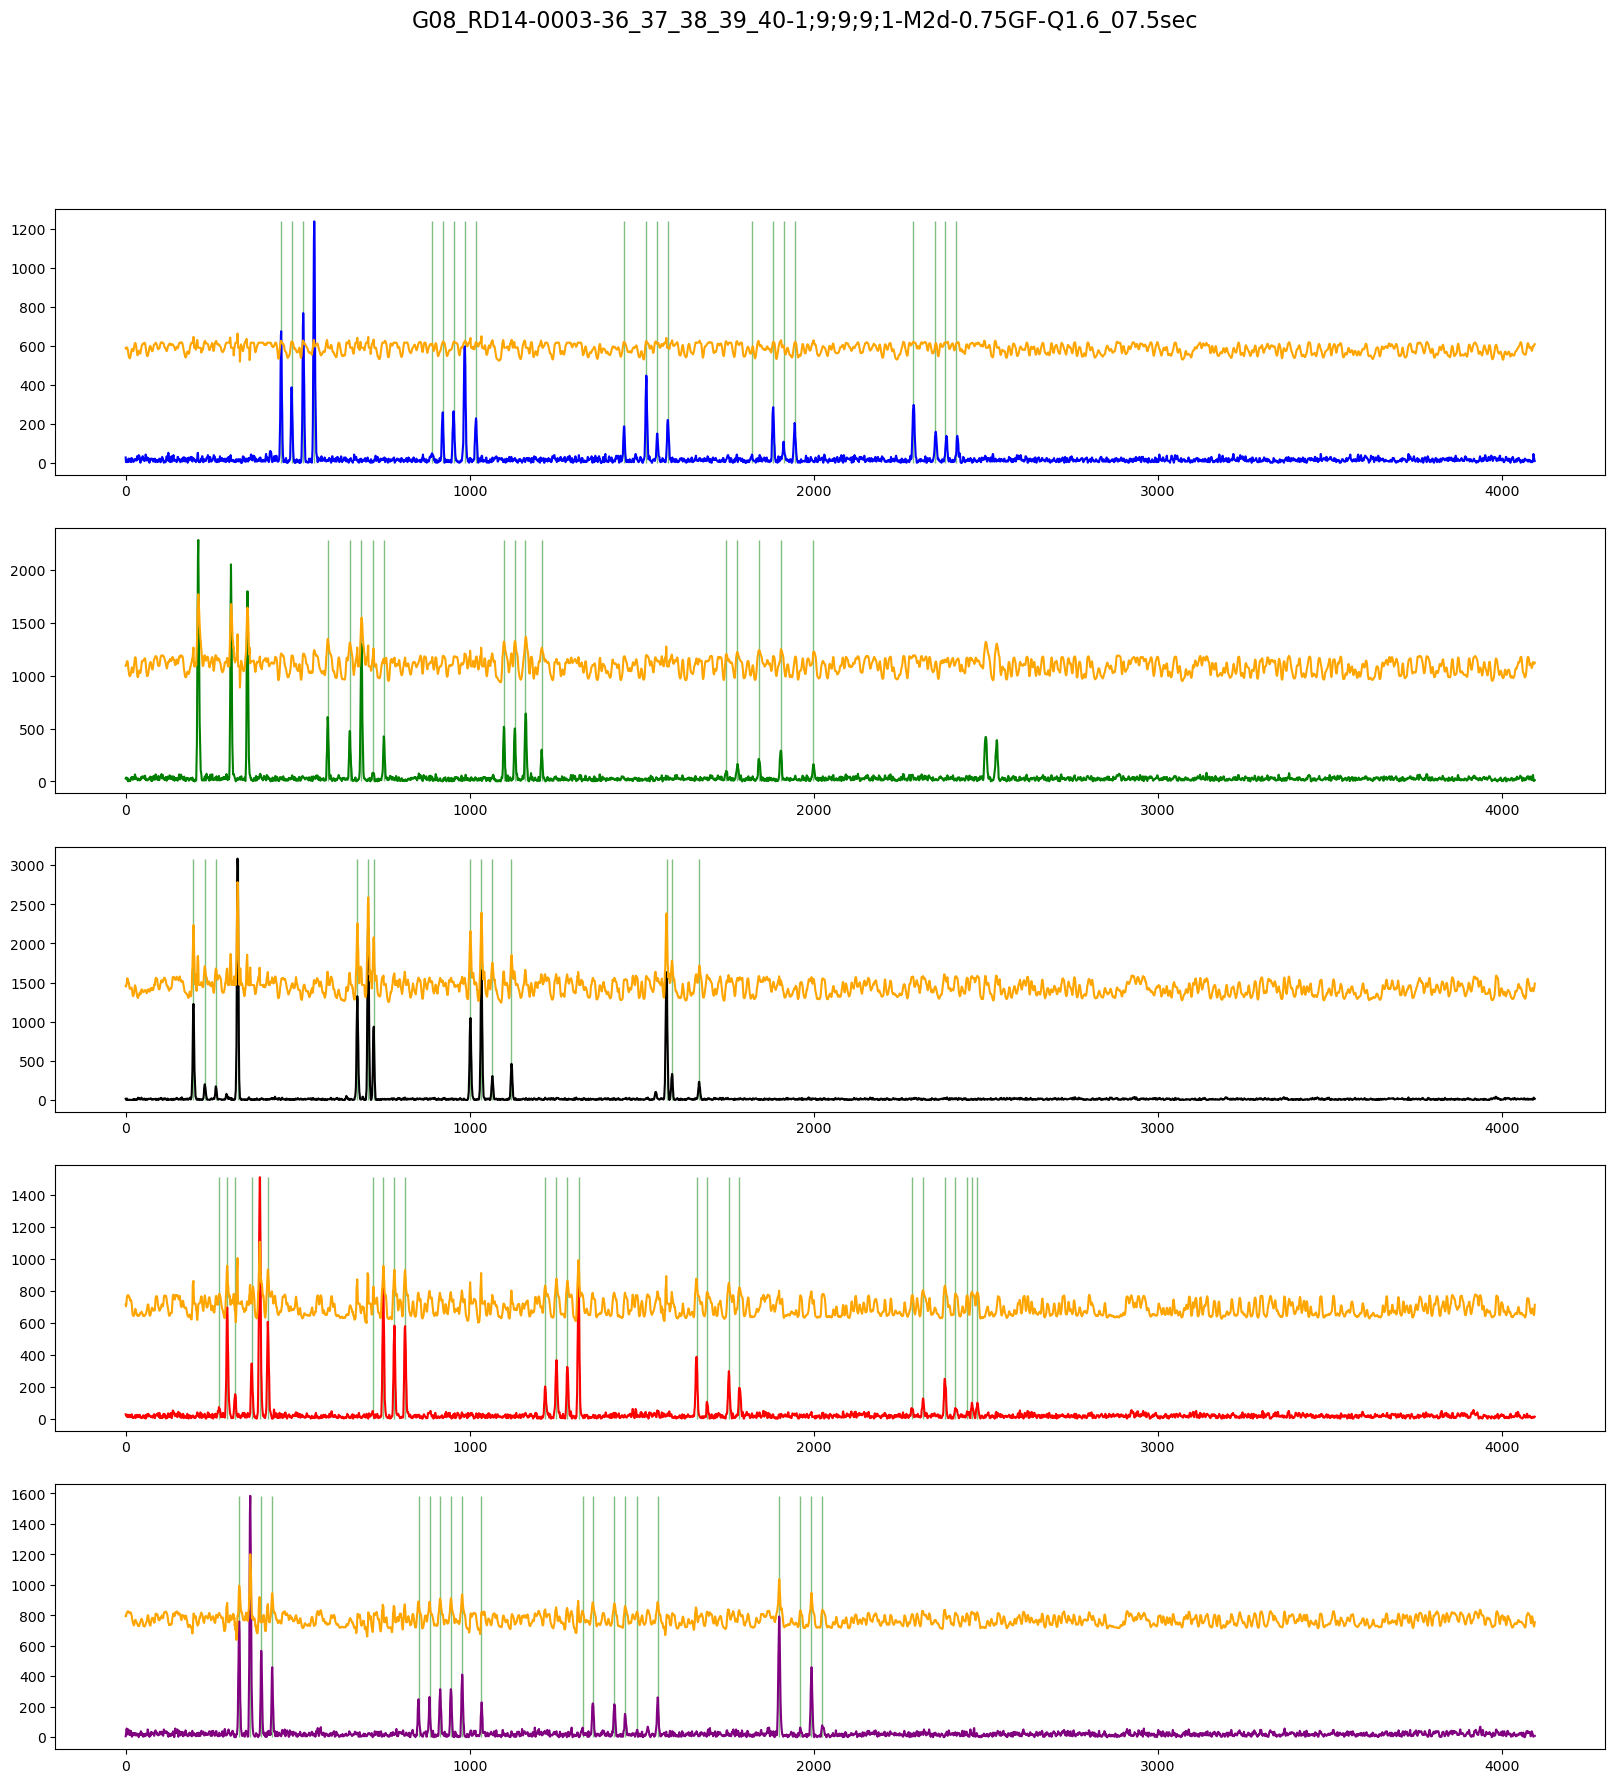

2025-06-27 17:25:21 INFO     Saved best model with loss 0.990770 at epoch 1.
2025-06-27 17:25:21 INFO     Epoch 1/10: scheduler decreased learning rate to 0.009000000000000001
Epoch 2/10: 100%|██████████| 12/12 [00:03<00:00,  3.32it/s, training_loss=0.987]
2025-06-27 17:25:24 INFO     Epoch 2/10 - Training binaryaccuracy: 0.762958
2025-06-27 17:25:24 INFO     Epoch 2/10 - Training loss: 0.987005
Epoch 2/10: 2it [00:00, 12.59it/s, validation_loss=0.987]               
2025-06-27 17:25:25 INFO     Epoch 2/10 - Validation metric (BinaryAccuracy()): 0.855359 | Validation loss: 0.987120
2025-06-27 17:25:25 INFO     Epoch 2/10 - Validation binaryaccuracy: 0.845139
2025-06-27 17:25:25 INFO     Calling alleles from predicted segmentation...
2025-06-27 17:25:27 INFO     Saved best model with loss 0.987120 at epoch 2.
2025-06-27 17:25:27 INFO     Epoch 2/10: scheduler decreased learning rate to 0.008100000000000001
Epoch 3/10: 100%|██████████| 12/12 [00:03<00:00,  3.34it/s, training_loss=0.982]


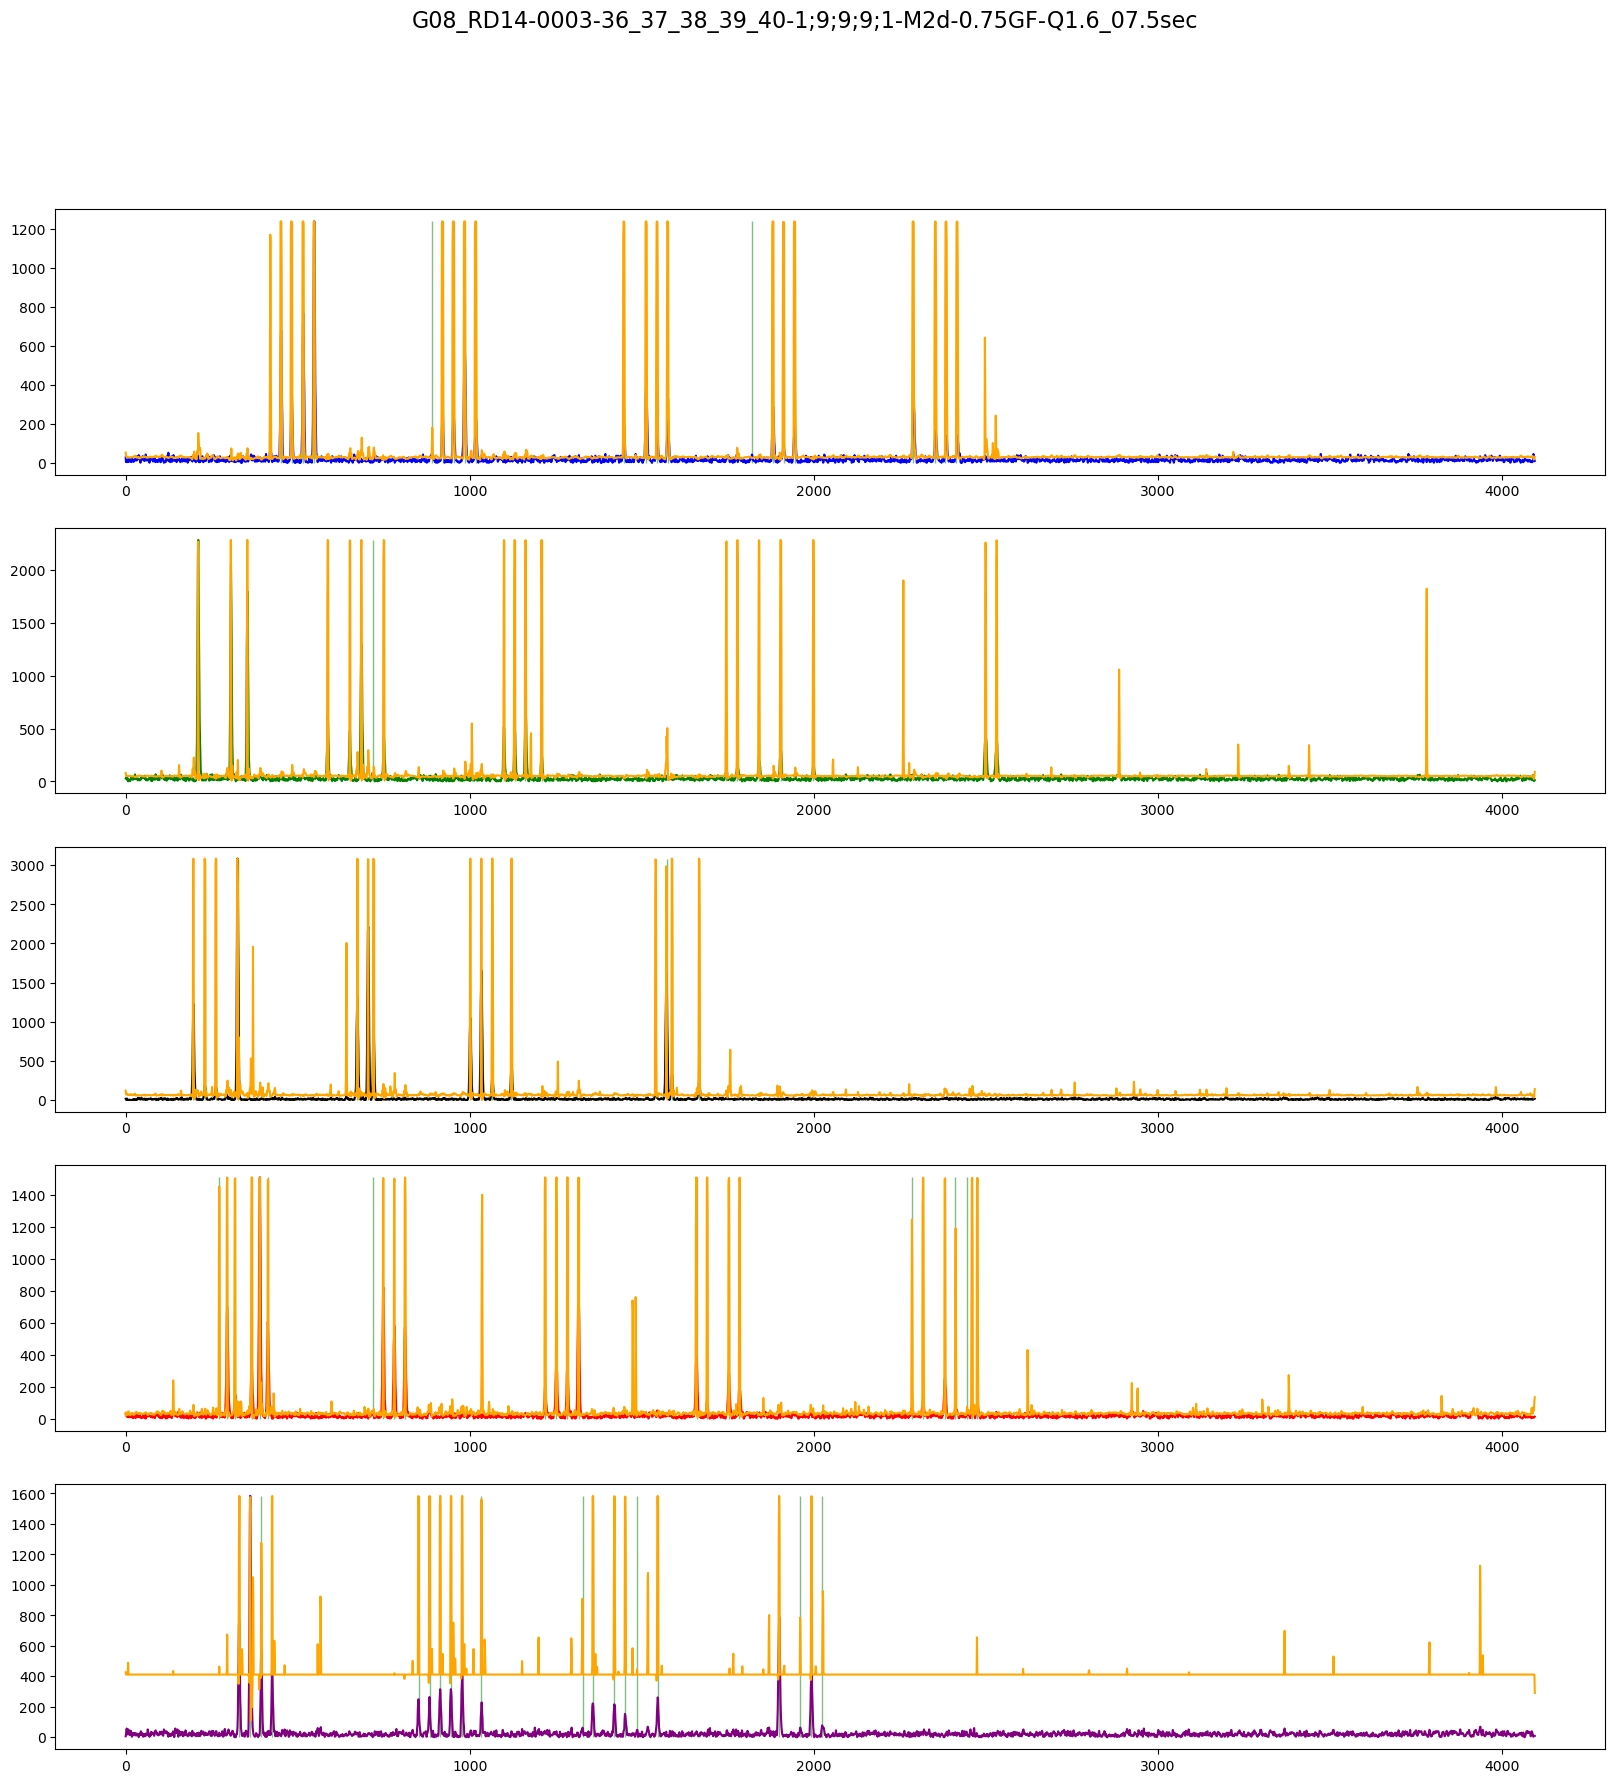

2025-06-27 17:26:08 INFO     Saved best model with loss 0.923097 at epoch 10.
2025-06-27 17:26:08 INFO     Epoch 10/10: scheduler decreased learning rate to 0.003486784401000002
2025-06-27 17:26:08 INFO     Restored previous best model
2025-06-27 17:26:08 INFO     Calling alleles from predicted segmentation...
[neptune] [warning] NeptuneUnsupportedType: You're attempting to log a type that is not directly supported by Neptune (<class 'list'>).
        Convert the value to a supported type, such as a string or float, or use stringify_unsupported(obj)
        for dictionaries or collections that contain unsupported values.
        For more, see https://docs-legacy.neptune.ai/help/value_of_unsupported_type
2025-06-27 17:26:09 INFO     Model checkpoint saved to output/real_data-best_unet-use_scheduler-delta_0.01_100-epoch/20250627_172414/checkpoint
2025-06-27 17:26:09 INFO     Config written to output/real_data-best_unet-use_scheduler-delta_0.01_100-epoch/20250627_172414/config_used.yaml


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 15 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 15 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/amar-mesic/dna-thesis/e/DNAT-43/metadata


In [3]:
run(
    data_config="provedit_data.yaml",
    model_config="unet_amar_1.yaml",
    training_config="training_amar.yaml",
)

In [4]:
from config_io import load_model

unet_model = load_model("config/models/unet_amar_1.yaml")
unet_model.load("output/real_data-best_unet-use_scheduler-delta_1/checkpoint/")

In [5]:
from DNAnet.data.data_models import Panel
from DNAnet.data.data_models.custom_hid_dataset import CustomHIDDataset
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer
from DNAnet.data.parsing.file_parsing import find_files_by_suffix
from DNAnet.data.validation.sample_validation_strategy import NFIValidationStrategy
from DNAnet.data.kit_compatibility.lane_standards import InternalSizeStandard


from typing import List
from pathlib import Path

gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"
reference_genotype_path = "/Users/amarmesic/Documents/tudelft/thesis/DNANet/resources/data/ProvedIt/References"

panel = Panel(gf_panel_path)
hid_files = find_files_by_suffix(hid_files_path, ".hid")
file_categorizer = ProvedItFileCategorizer()
sample_validator = NFIValidationStrategy()

images = CustomHIDDataset(
    root_path=hid_files_path,
    panel_path=gf_panel_path,
    size_standard=InternalSizeStandard.GENESCAN_600_LIZ.value,
    file_categorization_strategy=file_categorizer,
    sample_validation_strategy=sample_validator,
)

2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation on

In [6]:
predictions = unet_model.predict_batch(images)

2025-06-27 17:26:23 INFO     Calling alleles from predicted segmentation...
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:26:23 WARNING  No predictions present in dye row 4
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:26:23 WARNING  No predictions present in dye row 4
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:

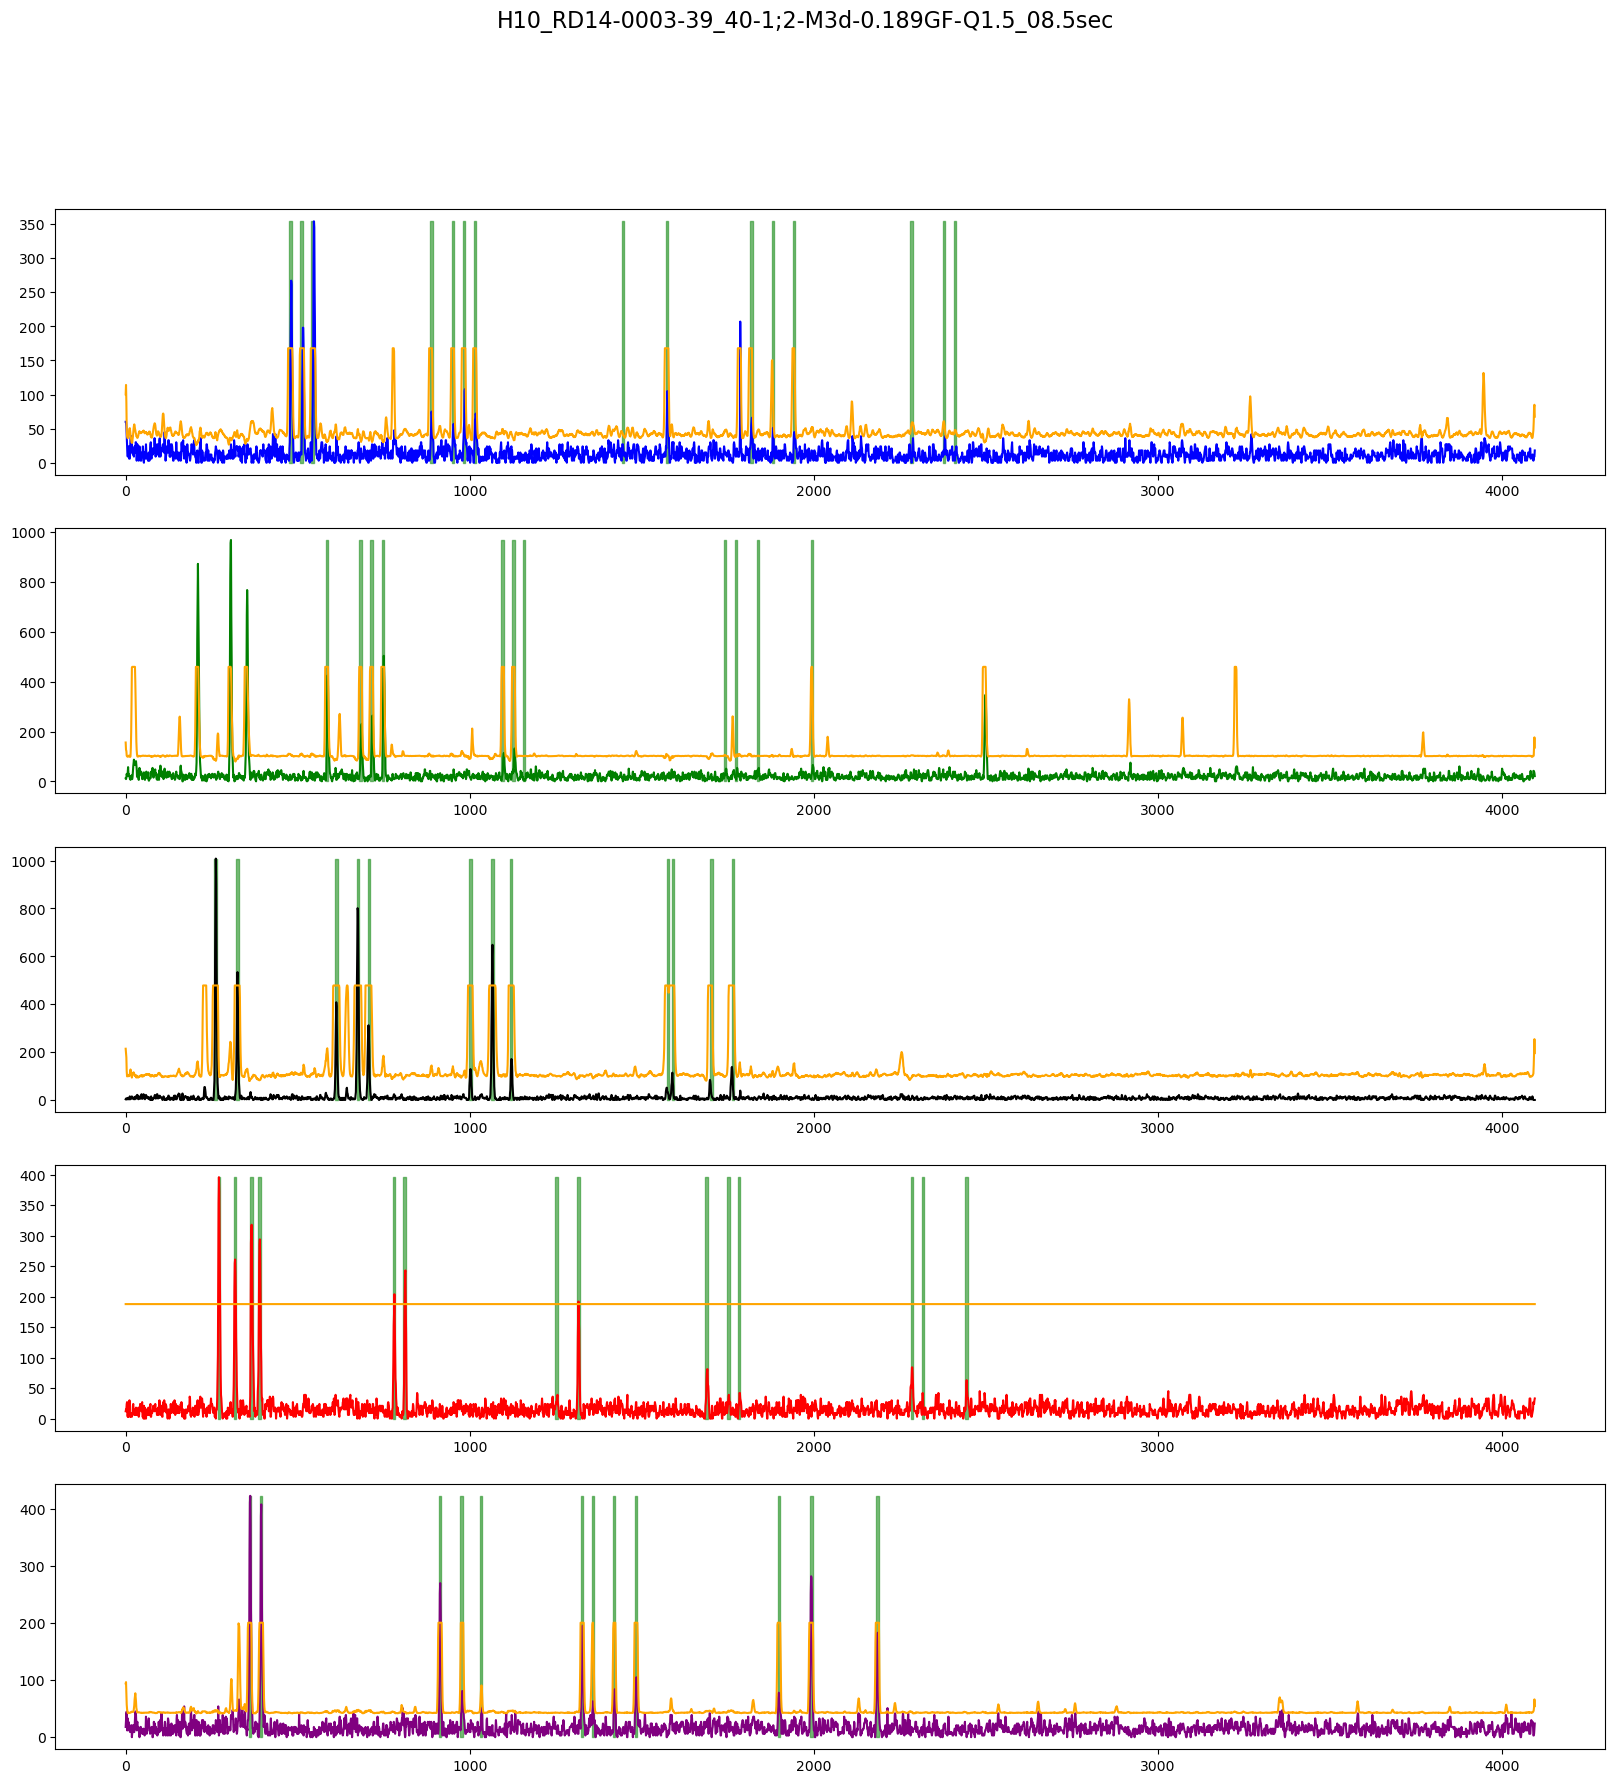

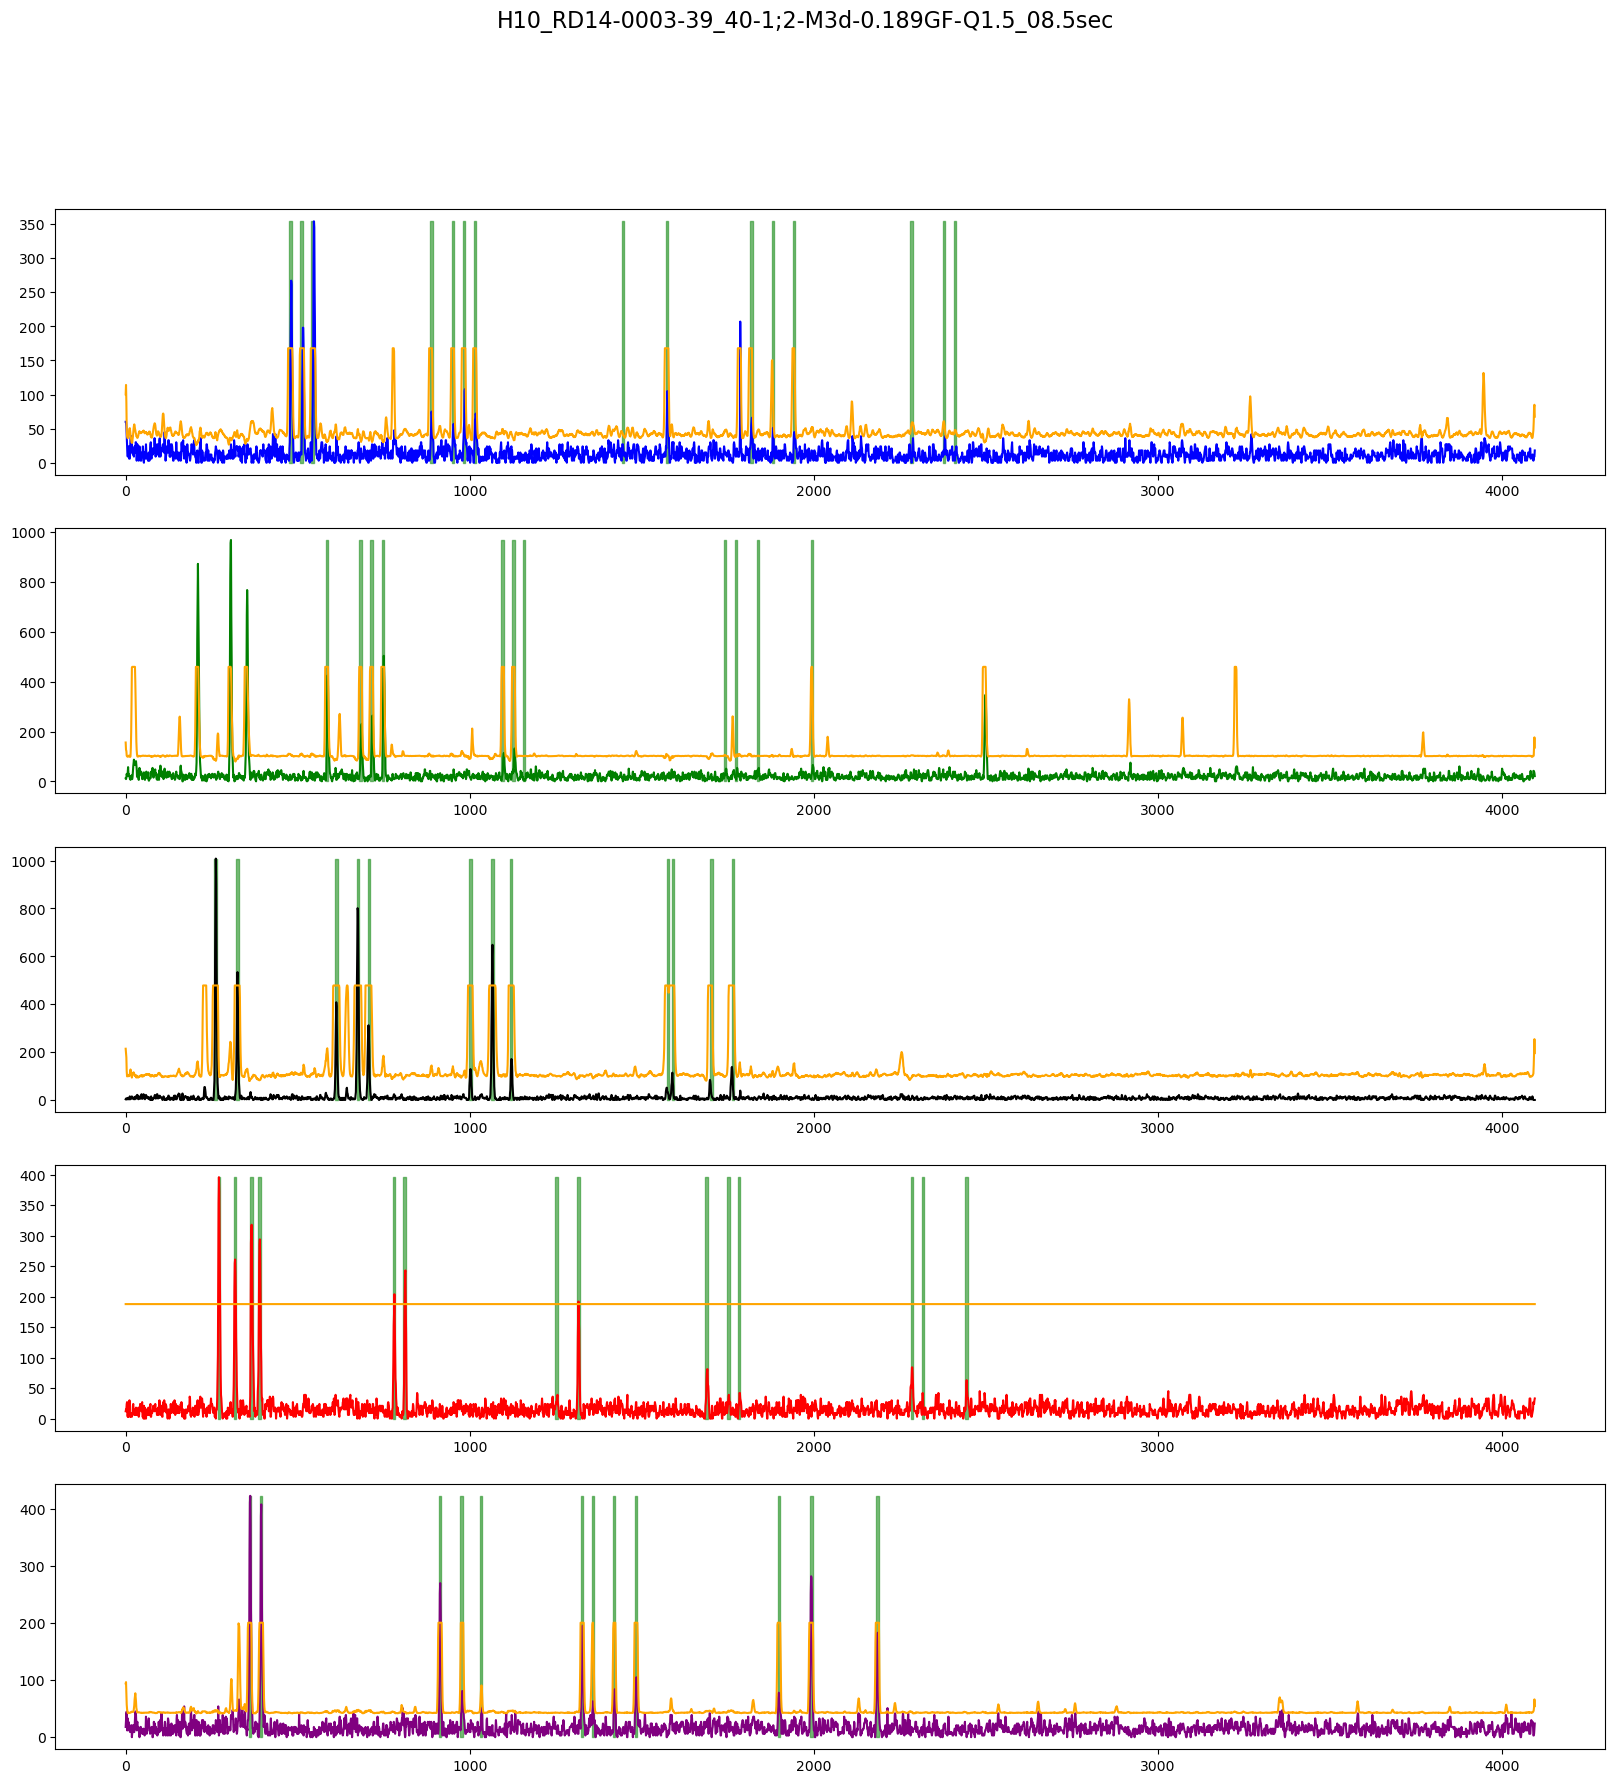

In [7]:
from DNAnet.evaluation.visualizations import plot_profile


plot_profile(images[:1], predictions[:1], prediction_as_mask=False)

In [8]:
best_unet_model = load_model("config/models/unet.yaml")
best_unet_model.load("resources/model/current_best_unet/")

In [9]:
best_predictions = best_unet_model.predict_batch(images[:1])

2025-06-27 17:26:35 INFO     Calling alleles from predicted segmentation...


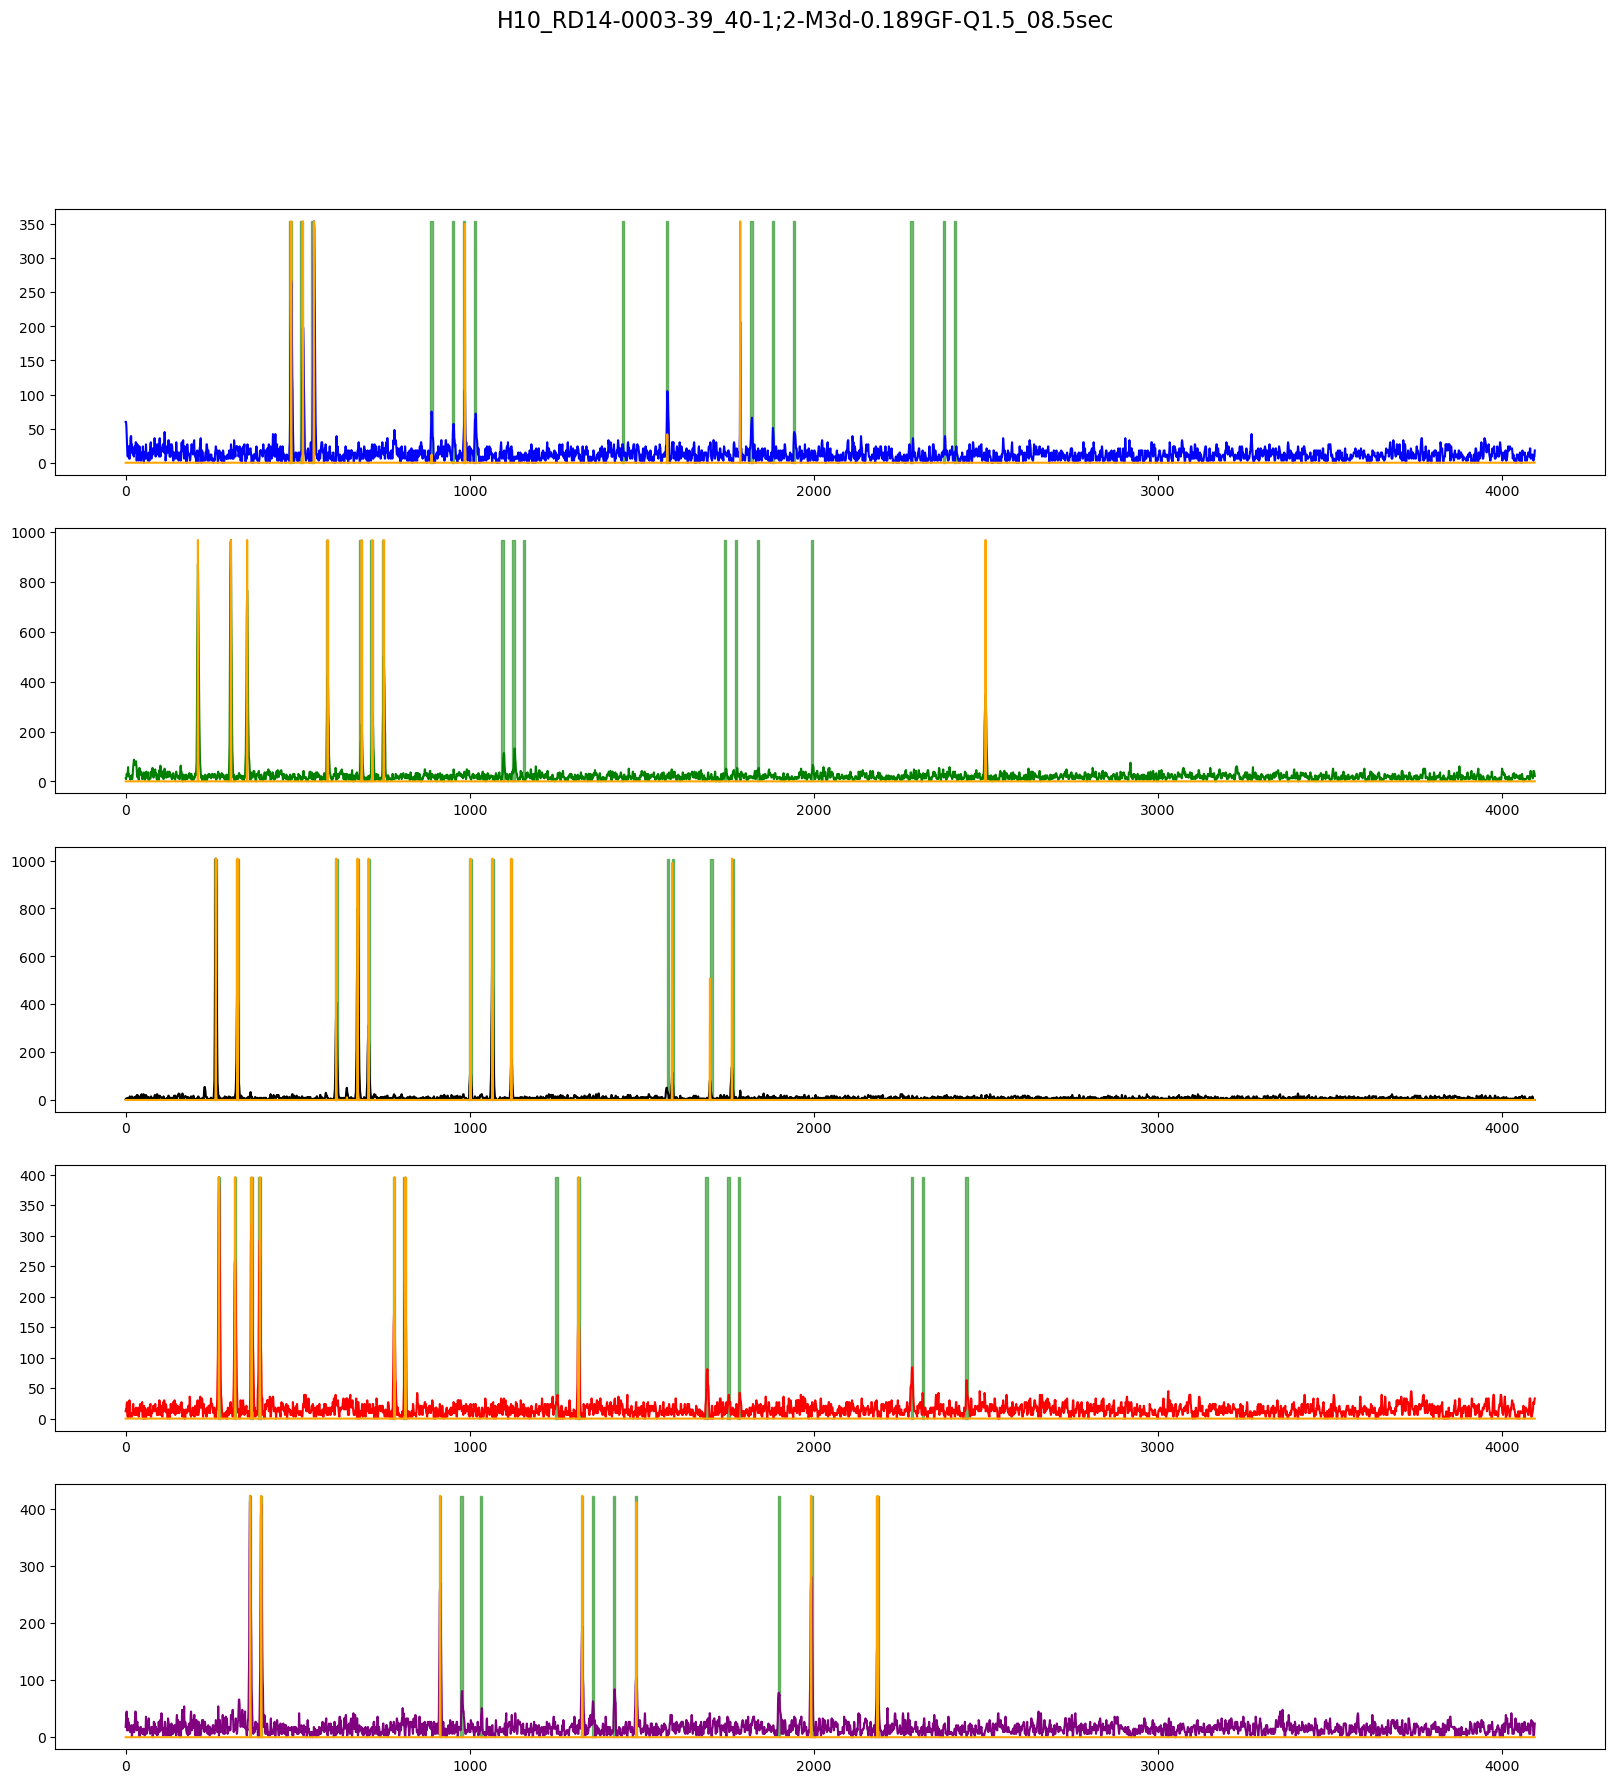

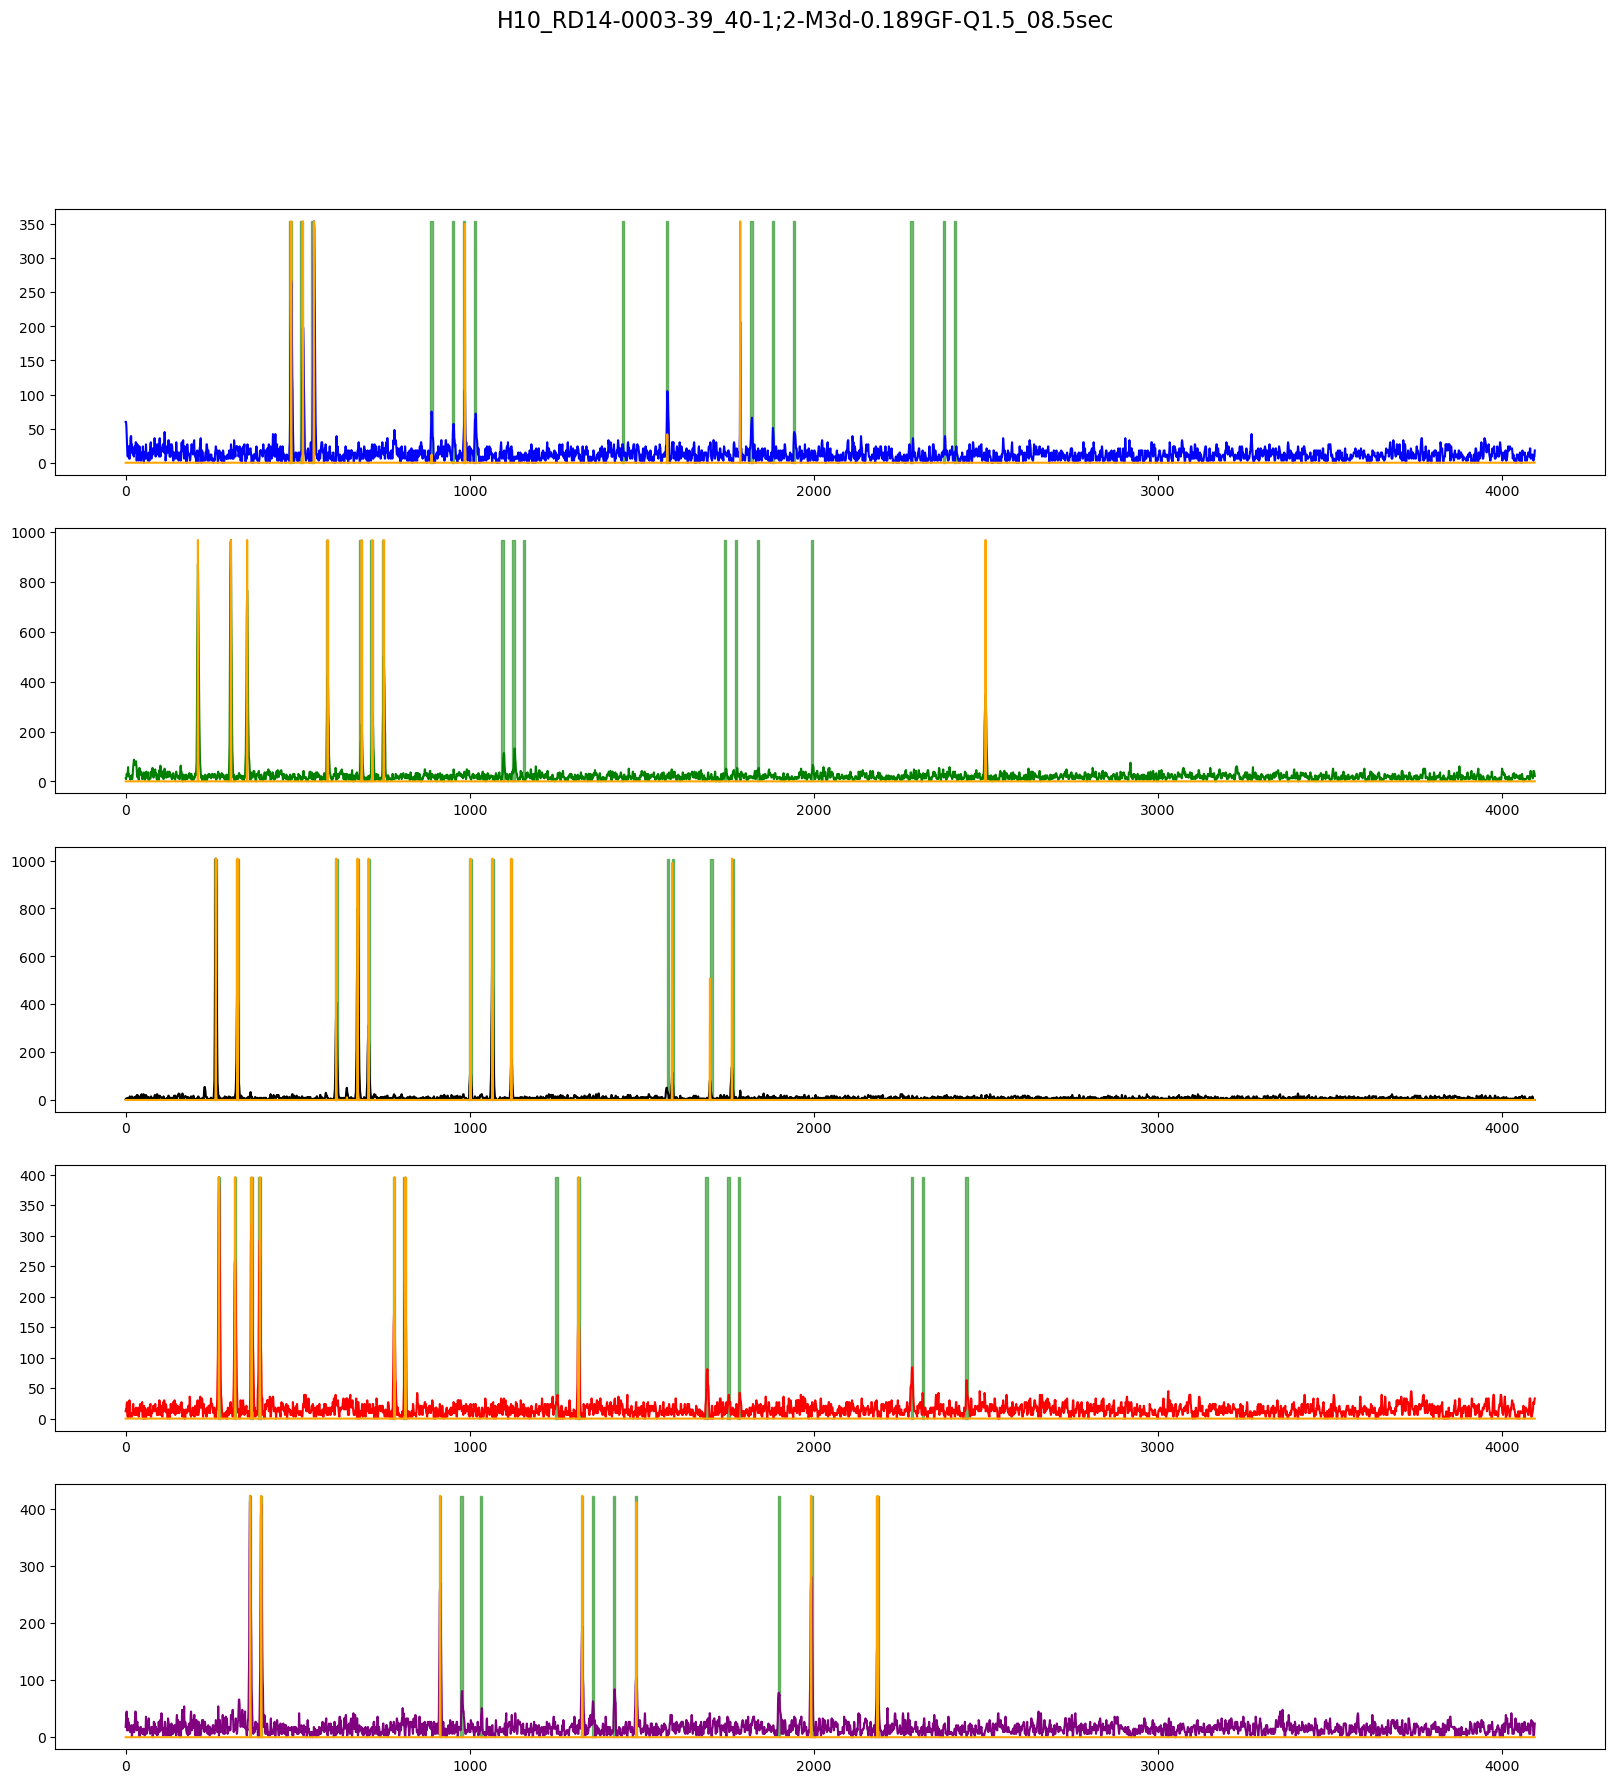

In [10]:
plot_profile(images[:1], best_predictions[:1], prediction_as_mask=False)